<a href="https://colab.research.google.com/github/jayden14141/Network-Anomaly-Detection/blob/main/ml/notebooks/03_models_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Markov Chain anomaly detection
# Learn normal traffic state transitions, flag low-probability sequences

import pandas as pd
import numpy as np
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Load data
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    data = pd.read_csv('/content/drive/MyDrive/cicids2017_selected.csv')
    print(f"Loaded from Drive: {data.shape}")
except:
    from google.colab import files
    uploaded = files.upload()
    data = pd.read_csv('cicids2017_selected.csv')
    print(f"Loaded from upload: {data.shape}")

Mounted at /content/drive
Loaded from Drive: (2827876, 47)


In [6]:
feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols.remove('is_attack')
print(f"Number of features: {len(feature_cols)}")

X = data[feature_cols]
y = data['is_attack']
print(f"X: {X.shape}, y: {y.shape}")

Number of features: 45
X: (2827876, 45), y: (2827876,)


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")
print(f"Train attack ratio: {y_train.mean():.3f}")
print(f"Test attack ratio: {y_test.mean():.3f}")

Train: (2262300, 45)
Test: (565576, 45)
Train attack ratio: 0.197
Test attack ratio: 0.197


In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Train Isolation Forest (unsupervised - only learns "benign" data)
X_train_benign = X_train_scaled[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.2,
    random_state=42
)
iso_forest.fit(X_train_benign)

# Predict on test set (-1 = anomaly, 1 = normal)
y_pred_raw = iso_forest.predict(X_test_scaled)

# Convert: -1 → 1 (attack), 1 → 0 (benign)
y_pred = (y_pred_raw == -1).astype(int)

# Results
print("Isolation Forest Results:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")

Isolation Forest Results:
              precision    recall  f1-score   support

      Benign       0.86      0.80      0.83    454265
      Attack       0.36      0.47      0.41    111311

    accuracy                           0.73    565576
   macro avg       0.61      0.63      0.62    565576
weighted avg       0.76      0.73      0.75    565576

Confusion Matrix:
[[363418  90847]
 [ 59182  52129]]


In [9]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Attack']))
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")

# Suspected data leakage - f1 score 1.00

XGBoost Results:
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00    454265
      Attack       1.00      1.00      1.00    111311

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576

Confusion Matrix:
[[453966    299]
 [   129 111182]]


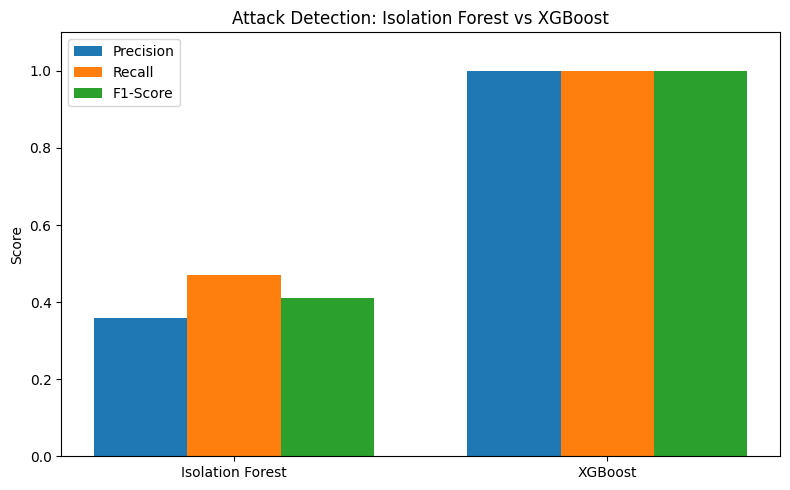

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Compare models
models = ['Isolation Forest', 'XGBoost']
precision = [0.36, 1.00]
recall = [0.47, 1.00]
f1 = [0.41, 1.00]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width, precision, width, label='Precision')
ax.bar(x, recall, width, label='Recall')
ax.bar(x + width, f1, width, label='F1-Score')

ax.set_ylabel('Score')
ax.set_title('Attack Detection: Isolation Forest vs XGBoost')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [12]:
# EWMA anomaly detection
# Instead of fixed thresholds, detect deviations from expected traffic patterns

# Select rate-based features relevant to network attacks
rate_features = ['Flow Duration', 'Total Fwd Packets',
                 'Fwd Packets/s', 'Bwd Packets/s']

# Get test data as DataFrame (before scaling, EWMA needs original values)
X_test_df = pd.DataFrame(X_test, columns=feature_cols)

# Calculate EWMA (span=20 means recent ~20 rows have most weight)
ewma_values = X_test_df[rate_features].ewm(span=20).mean()

# Residual = how far actual value is from EWMA prediction
residuals = np.abs(X_test_df[rate_features].values - ewma_values.values)

# Anomaly score = average residual across all rate features
anomaly_score = residuals.mean(axis=1)

# Threshold: mean + 2*std (statistically, top ~5% are flagged)
threshold = anomaly_score.mean() + 2 * anomaly_score.std()
y_pred_ewma = (anomaly_score > threshold).astype(int)

print("EWMA Results:")
print(classification_report(y_test, y_pred_ewma, target_names=['Benign', 'Attack']))
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred_ewma)}")
print(f"\nThreshold: {threshold:.4f}")
print(f"Flagged as attack: {y_pred_ewma.sum()} / {len(y_pred_ewma)}")

EWMA Results:
              precision    recall  f1-score   support

      Benign       0.83      0.94      0.88    454265
      Attack       0.43      0.19      0.26    111311

    accuracy                           0.79    565576
   macro avg       0.63      0.56      0.57    565576
weighted avg       0.75      0.79      0.76    565576

Confusion Matrix:
[[425332  28933]
 [ 89892  21419]]

Threshold: 16753348.6978
Flagged as attack: 50352 / 565576


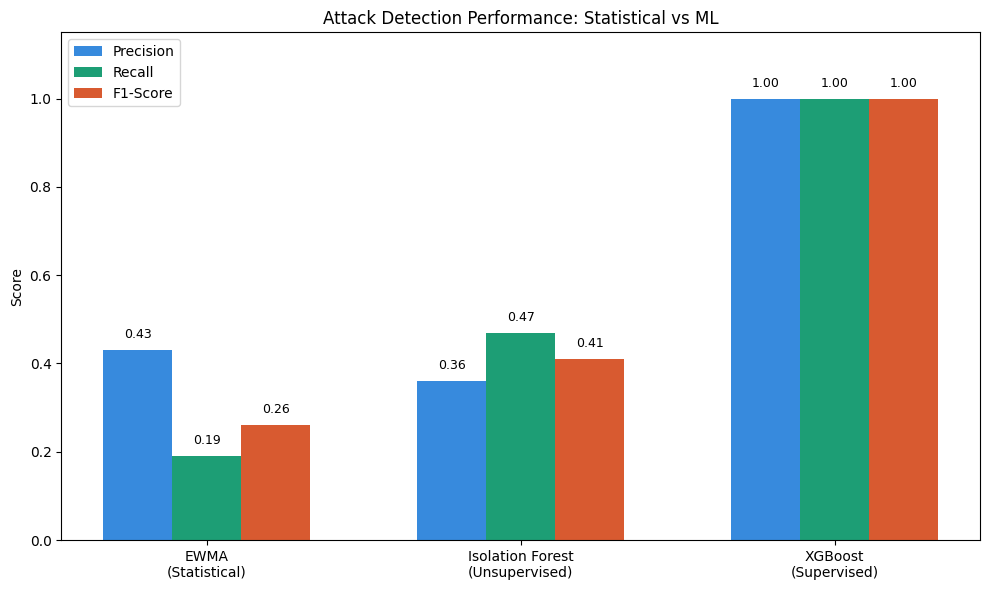

In [13]:
import matplotlib.pyplot as plt
import numpy as np

models = ['EWMA\n(Statistical)', 'Isolation Forest\n(Unsupervised)', 'XGBoost\n(Supervised)']
precision = [0.43, 0.36, 1.00]
recall = [0.19, 0.47, 1.00]
f1 = [0.26, 0.41, 1.00]

x = np.arange(len(models))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', color='#378ADD')
bars2 = ax.bar(x, recall, width, label='Recall', color='#1D9E75')
bars3 = ax.bar(x + width, f1, width, label='F1-Score', color='#D85A30')

ax.set_ylabel('Score')
ax.set_title('Attack Detection Performance: Statistical vs ML')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.15)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()